📅 **论文年份 (Year):2020 / 2022 年**
*Denoising Diffusion Probabilistic Models (DDPM) — Ho, Jain & Abbeel, 2020*
*Classifier-Free Diffusion Guidance — Ho & Salimans, 2022*

# Bonus Paper 35: 文生图扩散模型(DDPM + Classifier-Free Guidance)
## Ho, Jain & Abbeel (2020) + Ho & Salimans (2022)

### Implementation: Text-to-Image Diffusion from Scratch(实现:NumPy 从零实现文本条件扩散模型)

This notebook implements a **text-conditioned denoising diffusion model** using only NumPy: a closed-form forward noising process, an MLP noise-predictor trained with plain MSE (manual backprop), DDPM ancestral sampling, and **classifier-free guidance (CFG)** — the exact mechanism that makes Stable Diffusion follow your prompt.

本笔记本只用 NumPy 实现一个**文本条件扩散模型**:前向加噪的闭式公式、用纯 MSE 训练的 MLP 噪声预测网络(手写反向传播)、DDPM 祖先采样,以及**无分类器引导(CFG)**——这正是让 Stable Diffusion 听懂提示词的那套机制。最后用一个独立训练的"评委"分类器给出硬数字:CFG 把提示词依从率从多少提到多少。

> 注:本篇不在 Sutskever 原始 30 篇书单中,是本仓库的多模态扩展(Bonus)。前面 31-34 号覆盖了"理解"图像的一半(CLIP/ViT/BLIP-2/LLaVA),本篇补上"生成"图像的另一半。

## 📖 论文导读

**🎯 这篇文章想解决什么问题(目的):** 生成模型的老大难问题是:如何学到一个既**容易采样**又**表达力强**的图像分布?VAE(Paper 17)一步解码但被单峰高斯后验限制,样本偏模糊;GAN 画质好但训练不稳定、容易模式崩塌。DDPM(Ho et al., 2020)提出第三条路:把"生成"拆成几百步微小的去噪,每一步只需拟合一个小小的高斯——单步简单,复合起来却能表达任意复杂的分布。而 CFG(Ho & Salimans, 2022)解决的是条件生成的痛点:怎样让模型**严格听从**文本条件,而不需要额外训练一个分类器来引导?

**💡 主要贡献:** DDPM 的贡献:(1) 证明扩散模型的变分下界可以简化成一个**纯 MSE 噪声回归损失** L_simple = ‖ε − ε̂‖²,训练稳定得像训一个去噪自编码器;(2) 关键设计是让网络**预测噪声 ε 而不是干净图像 x₀**;(3) 闭式跳步公式 q(x_t|x₀) = N(√ᾱ_t·x₀, (1−ᾱ_t)I) 让训练可以随机抽任意时间步、完全并行。CFG 的贡献:训练时以小概率把条件替换成空条件(条件 dropout),一个模型同时学会条件与无条件去噪;采样时用 ε̂ = ε_uncond + w·(ε_cond − ε_uncond) 外推,**不需要任何外部分类器**就能大幅提升条件符合度。

**🔧 方法:** 前向过程按噪声日程表(本文用余弦 schedule)逐步把图像淹没成纯高斯噪声;网络学习反向过程:输入带噪图像 x_t、时间步 t(正弦嵌入)和文本条件,输出对所加噪声的预测 ε̂。采样从纯噪声出发,用 DDPM 祖先采样公式一步步"减去"预测的噪声。本笔记本用 16×16 彩色几何图形(3 色 × 3 形 = 9 类)作为图像域,词袋向量作为文本条件,训练时 15% 概率丢弃条件,采样时扫描引导强度 w ∈ {0,1,2,4,8},并用一个 99.9% 准确率的评委分类器量化每档 w 的提示词依从率。

**🌟 意义:** DDPM + CFG 就是现代文生图的两块基石。Latent Diffusion(Rombach et al., 2022)在此之上只加了一步工程杠杆:先用 VAE 把 512×512 图像压缩到 64×64 潜空间,再在潜空间里跑与本笔记本一模一样的"加噪-预测 ε-CFG 采样"流程,文本条件换成 CLIP 文本编码器(Paper 31)的输出、去噪网络换成 U-Net + 交叉注意力——这就是 **Stable Diffusion**。理解了本笔记本的 200 行 NumPy,就理解了 DALL·E 2、Imagen、Stable Diffusion 共同的心脏。

## 🎯 核心结论 (Key Takeaways)

- **扩散训练本质上就是去噪回归。** 全部训练目标只是一个 MSE:随机抽一张图、一个时间步 t、一份噪声 ε,让网络从 x_t 中把 ε 猜回来。本实验损失平滑收敛到 **~0.32**(且大部分残余是低 t 处的不可约噪声),没有对抗训练、没有 KL 退火,稳定得像训练一个普通回归模型。

- **闭式跳步让训练 O(1)。** q(x_t|x₀) = N(√ᾱ_t·x₀, (1−ᾱ_t)I) 意味着到达任意 t 不需要模拟 t 步链条,一次采样直达。余弦 schedule 下 ᾱ₁₀₀ ≈ 0.494(信号剩一半)、ᾱ_T ≈ 6×10⁻⁸(信号基本清零)。

- **ε 预测的难度随 t 剧烈变化。** t=199 时 x_t 几乎就是 ε,MSE ≈ 0.000;t=5 时噪声只占图像的一小部分,本质不可预测,MSE ≈ 0.94。中间时间步(t≈50-120)才是形状与颜色被"决定"的关键区间。

- **CFG 提供了免费的条件增强。** 评委分类器(真实数据准确率 **99.9%**)测得提示词依从率:无条件(w=0)**11.1%**(=1/9 随机水平),纯条件(w=1)**80.0%**,而 CFG 外推 w=2/4/8 分别达到 **90.7% / 93.8% / 98.2%**——超过 80% 的目标线,给"CFG 有效"钉上硬数字。

- **w 是"贴合度 vs 多样性"的旋钮。** 同一批初始噪声下,w=0 生成五颜六色的随机类别;w 增大后样本全部收敛到提示词类别,但彼此越来越像——与 Stable Diffusion 里 guidance scale 的手感完全一致。

- **颜色比形状容易。** w=4 时颜色正确率 100%,形状正确率约 94%:颜色是全局统计量(一层线性即可分离),形状是空间结构(MLP 去噪器的短板)——这正是真实扩散模型使用 U-Net 处理空间结构的原因。

## 🤯 反常识的发现 (Counterintuitive Findings)

- **常识认为:要生成图像,网络就该输出图像。** DDPM 反其道而行:网络输出的是**噪声**。原因很实际:ε 的方差在所有时间步都恒为 1(回归目标尺度统一),而 x₀ 的"可见度"随 t 剧烈变化;而且 x̂₀ 可以由 x_t 和 ε̂ 线性换算,预测 ε 等价于预测 x₀,但数值上稳定得多。本实验中同一个网络在 t=199 的 ε-MSE 是 0.000、t=5 是 0.94——如果直接回归 x₀,难度曲线正好反过来,低噪声步反而简单、高噪声步近乎瞎猜。

- **常识认为:无条件模型是没用的副产品。** CFG 恰恰要**故意**训练无条件模型(本实验 15% 概率把文本条件清零),因为引导方向 = ε_cond − ε_uncond,即"有了这句话之后,去噪方向改变了多少"。更反直觉的是 w>1 属于**外推**——采样时使用训练中从未见过的组合系数——却把依从率从 80% 推到 98.2%。变强不是靠更好的条件模型,而是靠减去一个"更差"的模型。

- **常识认为:破坏信息(加噪)对学习毫无价值。** 前向加噪恰恰是一份精心设计的**课程表**:它把"从纯噪声生成图像"这个不可学的问题,切成 200 个"去掉一点点噪声"的可学小问题,并且闭式跳步公式允许随机抽题、并行训练所有难度等级。生成模型的能力来自"破坏"的可控性。

- **常识认为:200 步迭代是低效的缺陷。** 迭代恰恰是扩散画质上限高于 VAE(Paper 17)的根本原因:VAE 解码器必须一步命中,输出分布被单峰高斯限死;扩散每步只拟合一个小高斯,200 个小高斯复合出的分布可以任意复杂。同一套 90 万参数被复用 200 次,等效计算深度是 VAE 解码器的两个数量级。

#### 💻 代码解读

**做什么:** 导入依赖并固定随机种子,保证实验可复现。

**怎么做:**
- 只用 `numpy`(数值计算)和 `matplotlib`(画图),与本仓库其他 notebook 保持一致——不依赖任何深度学习框架。
- 固定两个随机源:全局 `np.random.seed` 和新式 `default_rng(0)`;数据生成、参数初始化、训练全走 `rng`,采样和画图用独立种子的生成器,互不干扰,结果完全可复现。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
# 新式随机数生成器:数据、初始化、训练共用这一条随机流,保证可复现
rng = np.random.default_rng(0)

## Synthetic Text-Image Dataset(合成文-图数据集)

#### 💻 代码解读

**做什么:** 构造文生图训练数据:图像是 16×16 的彩色几何图形(3 色 × 3 形 = 9 类),文本是三词句子(如 "a red circle")的词袋向量。

**怎么做:**
- `draw_image`:带噪黑背景上画一个位置、大小随机抖动的图形。`np.mgrid` 一次生成全部像素坐标,再用布尔掩码向量化填色(圆=距离方程,方=切比雪夫距离,三角=半平面交集),与 Paper 31 (CLIP) 的生成器同源。
- 像素从 [0,1] 线性映射到 **[-1,1]**:扩散模型的惯例,让数据均值接近 0、尺度与标准高斯噪声匹配。
- `caption_bow`:文本条件用 7 维词袋向量表示;**全零向量约定为"空条件" ∅**,这是后面 classifier-free guidance 的关键接口。
- 演示图用独立的 `rng_vis`,不消耗训练随机流。

Training set: 4000 images, dim=768, range [-1.00, 1.00]


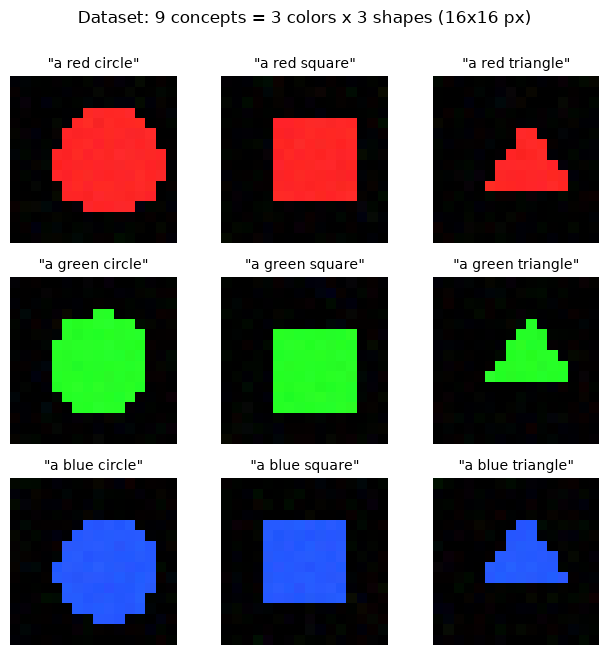

In [2]:
# 3种颜色 × 3种形状 = 9个概念,词表7个词
COLORS = {'red': (1.0, 0.15, 0.15), 'green': (0.15, 1.0, 0.15), 'blue': (0.15, 0.35, 1.0)}
SHAPES = ['circle', 'square', 'triangle']
VOCAB = ['a', 'red', 'green', 'blue', 'circle', 'square', 'triangle']
W2I = {w: i for i, w in enumerate(VOCAB)}
IMG = 16
ALL_PAIRS = [(c, s) for c in COLORS for s in SHAPES]
D_X = IMG * IMG * 3  # 展平后图像维度 768

def draw_image(color, shape, rng):
    """Draw one colored shape with position/size jitter and pixel noise"""
    img = np.zeros((IMG, IMG, 3))
    img += rng.normal(0, 0.015, img.shape)  # background noise
    # 位置和大小随机抖动:模型必须学"概念"而非死记像素
    cx, cy = rng.uniform(7.0, 9.0, 2)
    r = rng.uniform(4.3, 5.3)
    # np.mgrid一次生成所有像素的(行,列)坐标网格,形状均为(16,16)
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    if shape == 'circle':
        # 布尔掩码:到圆心距离平方<=r^2的像素为True,向量化代替双重循环
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    elif shape == 'square':
        mask = (np.abs(xx - cx) <= r * 0.8) & (np.abs(yy - cy) <= r * 0.8)
    else:  # triangle
        # 三角形=三条边的半平面交集:顶点在上,宽度随y线性增大
        mask = (yy - (cy - r) >= 0) & (yy - (cy - r) <= 1.5 * r) & \
               (np.abs(xx - cx) <= (yy - (cy - r)) / 1.5)
    img[mask] = COLORS[color]
    img += rng.normal(0, 0.01, img.shape)
    return np.clip(img, 0, 1)

def caption_bow(color, shape):
    """Caption 'a {color} {shape}' as a bag-of-words vector"""
    # 词袋表示:7维向量记录词频;全零向量保留给"空条件"(CFG的接口)
    v = np.zeros(len(VOCAB))
    for w in ['a', color, shape]:
        v[W2I[w]] += 1
    return v

def make_dataset(n, rng):
    """Generate n (image, caption, label) triples, images scaled to [-1,1]"""
    X, C, y = [], [], []
    for _ in range(n):
        k = int(rng.integers(9))
        c, s = ALL_PAIRS[k]
        # 像素映射到[-1,1]:扩散模型惯例,与标准高斯噪声的尺度匹配
        X.append(draw_image(c, s, rng).reshape(-1) * 2 - 1)
        C.append(caption_bow(c, s))
        y.append(k)
    return np.array(X), np.array(C), np.array(y)

X_train, C_train, y_train = make_dataset(4000, rng)
print(f'Training set: {X_train.shape[0]} images, dim={X_train.shape[1]}, range [{X_train.min():.2f}, {X_train.max():.2f}]')

# 演示图用独立随机流rng_vis,不影响训练可复现性
rng_vis = np.random.default_rng(123)
fig, axes = plt.subplots(3, 3, figsize=(6.5, 6.5))
for ax, (c, s) in zip(axes.flat, ALL_PAIRS):
    ax.imshow(draw_image(c, s, rng_vis))
    ax.set_title(f'"a {c} {s}"', fontsize=10)
    ax.axis('off')
plt.suptitle('Dataset: 9 concepts = 3 colors x 3 shapes (16x16 px)', y=1.0)
plt.tight_layout()
plt.show()

## Forward Diffusion: Closed-Form Noising(前向扩散:闭式加噪公式)

#### 💻 代码解读

**做什么:** 定义噪声日程表(余弦 schedule),并验证 DDPM 最重要的一条公式——**闭式跳步**:q(x_t|x₀) = N(√ᾱ_t·x₀, (1−ᾱ_t)I)。

**怎么做:**
- 前向过程每步加一点噪声:x_t = √(1−β_t)·x_{t-1} + √β_t·ε_t。**为什么可以一步跳到任意 t?** 因为两个独立高斯之和还是高斯:把递推展开,所有中间噪声合并成一个总噪声,方差恰好是 1−ᾱ_t(其中 ᾱ_t = ∏(1−β_s))。于是训练时**不需要模拟 t 步链条**,一行代码 `x_t = √ᾱ_t·x₀ + √(1−ᾱ_t)·ε` 直达——这就是重参数化技巧(Paper 17 VAE 的同款)在扩散里的用法。
- **余弦 schedule**(Nichol & Dhariwal, 2021):直接把 ᾱ_t 设计成余弦平方衰减,再反推出 β_t。对比图显示:线性 schedule 的 ᾱ_t 在中后段坠向 0 明显更快(t=T/3 处其实还剩 ᾱ≈0.57,但随后迅速耗尽),余弦 schedule 把"信号衰减预算"花得更均匀,给中等噪声区间(学习结构的关键区)留更多步数。
- 底部序列图:同一张图从 t=0 到 t=199 逐渐溺毙在噪声里,t=199 时 ᾱ ≈ 6×10⁻⁸,与纯高斯噪声无异。

cosine schedule: abar_50=0.847, abar_100=0.494, abar_199=6.07e-08


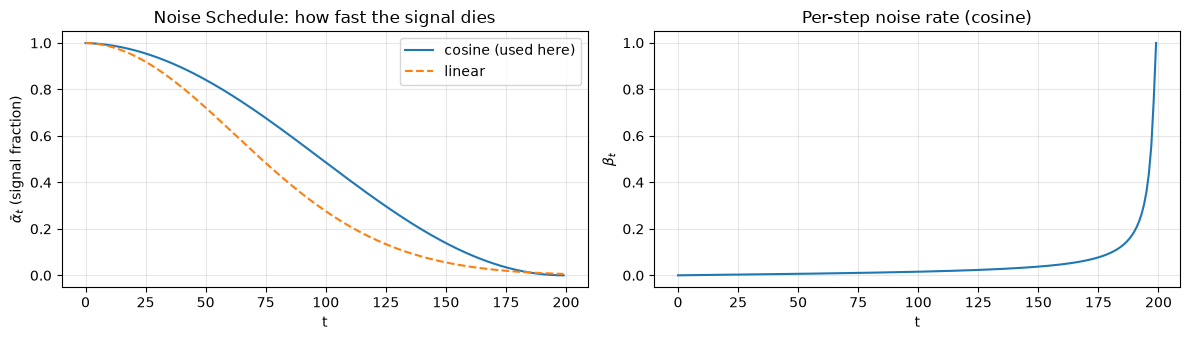

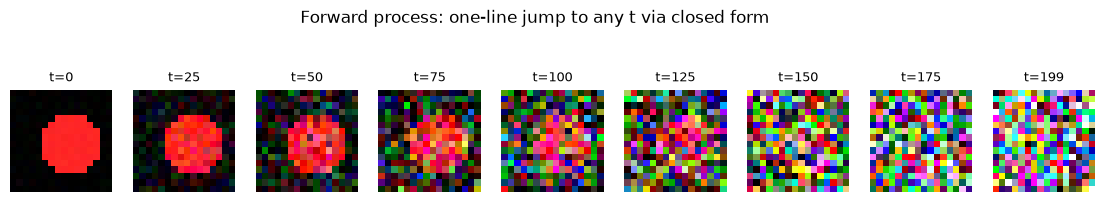

In [3]:
T = 200  # 扩散总步数:比DDPM原文的1000小,保证notebook几分钟内跑完

# 余弦schedule:先设计abar_t=cos^2(...)平滑衰减,再反推每步的beta_t
ss = 0.008  # 小偏移量:防止t=0处beta过小(Nichol & Dhariwal 2021)
f = np.cos((np.arange(T + 1) / T + ss) / (1 + ss) * np.pi / 2) ** 2
abar_full = f / f[0]
# beta_t = 1 - abar_t/abar_{t-1};裁剪防止最后几步beta→1导致数值问题
betas = np.clip(1 - abar_full[1:] / abar_full[:-1], 1e-5, 0.999)
alphas = 1.0 - betas
abar = np.cumprod(alphas)                     # \bar{alpha}_t = prod(1-beta_s)
abar_prev = np.concatenate([[1.0], abar[:-1]])  # \bar{alpha}_{t-1},反向采样要用
# 反向过程的后验方差 tilde{beta}_t(DDPM式(7))
post_var = betas * (1 - abar_prev) / (1 - abar)
sq_ab = np.sqrt(abar)      # 预存sqrt(abar_t):闭式跳步的信号系数
sq_1ab = np.sqrt(1 - abar)  # 预存sqrt(1-abar_t):闭式跳步的噪声系数

# 线性schedule(量级近似DDPM原版在T=200下的设置,非严格等比缩放)仅用于对比
abar_lin = np.cumprod(1 - np.linspace(1e-4, 0.05, T))
print(f'cosine schedule: abar_50={abar[49]:.3f}, abar_100={abar[99]:.3f}, abar_199={abar[-1]:.2e}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
ax1.plot(abar, label='cosine (used here)')
ax1.plot(abar_lin, '--', label='linear')
ax1.set_xlabel('t'); ax1.set_ylabel(r'$\bar{\alpha}_t$ (signal fraction)')
ax1.set_title('Noise Schedule: how fast the signal dies')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(betas)
ax2.set_xlabel('t'); ax2.set_ylabel(r'$\beta_t$')
ax2.set_title('Per-step noise rate (cosine)')
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 闭式跳步演示:一行代码直达任意t,无需模拟t步马尔可夫链
demo = draw_image('red', 'circle', np.random.default_rng(3)).reshape(-1) * 2 - 1
rng_fwd = np.random.default_rng(11)
ts_show = [0, 25, 50, 75, 100, 125, 150, 175, 199]
fig, axes = plt.subplots(1, len(ts_show), figsize=(14, 2))
for ax, tv in zip(axes, ts_show):
    # q(x_t|x_0)=N(sqrt(abar_t)x_0,(1-abar_t)I):高斯叠加的可重参数化
    xt = demo if tv == 0 else sq_ab[tv] * demo + sq_1ab[tv] * rng_fwd.normal(0, 1, demo.shape)
    ax.imshow(np.clip((xt.reshape(IMG, IMG, 3) + 1) / 2, 0, 1))
    ax.set_title(f't={tv}', fontsize=9)
    ax.axis('off')
plt.suptitle('Forward process: one-line jump to any t via closed form', y=1.15)
plt.show()

## Denoising Network: MLP Noise Predictor(去噪网络:MLP 噪声预测器)

#### 💻 代码解读

**做什么:** 定义去噪网络 ε̂ = f(x_t, t, cond):一个 2 隐层 MLP,输入是展平的带噪图像 + 正弦时间嵌入 + 词袋文本条件,输出是对噪声 ε 的预测。

**怎么做:**
- **正弦时间嵌入**:把整数 t 编码成 32 维的多频率 sin/cos 向量(与 Transformer 的位置编码同款,Paper 13),让网络平滑地感知"现在噪声有多大"。
- **文本条件直接拼接**(乘 4 放大,让 7 维条件在 807 维输入中不被淹没);真实模型(Stable Diffusion)用交叉注意力注入 CLIP 文本嵌入,机制不同、角色相同。
- **解析跳连(关键技巧)**:ε̂ = √(1−ᾱ_t)·x_t + MLP(...)。为什么?在高噪声端 x_t ≈ ε,最优预测几乎就是"抄输入",但 768→448 的瓶颈让 MLP 学恒等映射很吃力(原型实验中,去掉跳连后损失明显更高、样本无法收敛成形)。跳连把"抄输入"部分解析地送给网络,MLP 只学残差——这正是 ResNet(Paper 10/15)的残差学习思想。一个优雅的巧合:此时残差的回归目标恰好等于 √ᾱ_t·v,其中 v = √ᾱ_t·ε − √(1−ᾱ_t)·x₀ 就是后来 v-prediction 参数化(Salimans & Ho, 2022)的目标。
- `backward` 手写反向传播:MSE 损失让最外层梯度就是 2(ε̂−ε)/N,往回只是两次 ReLU 链式法则——比 Paper 31-34 的对比损失/注意力反传都简单,**因为扩散训练本质上就是去噪自编码器回归**。

In [4]:
D_T = 32          # 正弦时间嵌入维度
D_C = len(VOCAB)  # 文本条件维度(词袋)
D_IN = D_X + D_T + D_C  # 768+32+7=807
H = 448           # 隐层宽度

def time_embed(t):
    """Sinusoidal embedding of integer timesteps, (N,) -> (N, D_T)"""
    half = D_T // 2
    # 多频率:从1到1/10000几何递减,与Transformer位置编码同款(Paper 13)
    freqs = np.exp(-np.log(10000.0) * np.arange(half) / half)
    ang = t[:, None] * freqs[None, :]  # (N,1)*(1,half) 广播成 (N,half)
    return np.concatenate([np.sin(ang), np.cos(ang)], axis=1)

def init_mlp(rng):
    """He-initialized 2-hidden-layer MLP for noise prediction"""
    return {
        'W1': rng.normal(0, np.sqrt(2 / D_IN), (D_IN, H)), 'b1': np.zeros(H),
        'W2': rng.normal(0, np.sqrt(2 / H), (H, H)), 'b2': np.zeros(H),
        # 输出层初始化再乘0.1:训练起点接近"纯跳连",残差从小学起
        'W3': rng.normal(0, np.sqrt(2 / H), (H, D_X)) * 0.1, 'b3': np.zeros(D_X),
    }

def forward(p, xt, t, cond):
    """Predict noise: eps_hat = sqrt(1-abar_t)*x_t + MLP(x_t, t, cond)"""
    # 条件乘4放大:7维词袋在807维输入里不被淹没(SD用交叉注意力,这里用拼接)
    inp = np.concatenate([xt, time_embed(t), 4.0 * cond], axis=1)
    h1p = inp @ p['W1'] + p['b1']; h1 = np.maximum(h1p, 0)
    h2p = h1 @ p['W2'] + p['b2']; h2 = np.maximum(h2p, 0)
    resid = h2 @ p['W3'] + p['b3']
    # 解析跳连:高噪声端最优eps约等于x_t本身,让MLP只学残差(ResNet思想)
    # 数学巧合:残差目标 = eps - sqrt(1-abar)x_t = sqrt(abar)*v (v-parameterization)
    eps = sq_1ab[t][:, None] * xt + resid
    return eps, (inp, h1p, h1, h2p, h2)

def backward(p, cache, deps):
    """Manual backprop; deps = dL/d(eps_hat)"""
    inp, h1p, h1, h2p, h2 = cache
    # 跳连项sq_1ab*xt不含参数,梯度直接从resid回传即可
    g = {}
    g['W3'] = h2.T @ deps; g['b3'] = deps.sum(0)
    dh2 = deps @ p['W3'].T
    # ReLU梯度:前向为正处通过,否则截断为0
    dh2p = dh2 * (h2p > 0)
    g['W2'] = h1.T @ dh2p; g['b2'] = dh2p.sum(0)
    dh1 = dh2p @ p['W2'].T
    dh1p = dh1 * (h1p > 0)
    g['W1'] = inp.T @ dh1p; g['b1'] = dh1p.sum(0)
    return g

def adam_update(p, g, m, v, t, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    for k in p:
        m[k] = b1 * m[k] + (1 - b1) * g[k]
        v[k] = b2 * v[k] + (1 - b2) * g[k] ** 2
        # 偏差修正:除以(1-beta^t),抵消动量初始化为0造成的低估
        mh = m[k] / (1 - b1 ** t)
        vh = v[k] / (1 - b2 ** t)
        p[k] -= lr * mh / (np.sqrt(vh) + eps)

net = init_mlp(rng)
m = {k: np.zeros_like(v) for k, v in net.items()}
v = {k: np.zeros_like(vv) for k, vv in net.items()}
print(f'Denoiser params: {sum(p.size for p in net.values()):,}')

Denoiser params: 907,968


## Training: Denoising as Regression(训练:去噪即回归)

#### 💻 代码解读

**做什么:** 训练去噪网络 9000 步。每步就是 DDPM 论文的 Algorithm 1:抽图、抽 t、抽噪声、闭式加噪、回归 ε——外加 CFG 需要的**条件 dropout**。

**怎么做:**
- **条件 dropout(CFG 的训练侧)**:每个样本以 15% 概率把词袋条件清零。同一个网络因此同时学会两件事:p(ε|x_t, t, 文本) 和 p(ε|x_t, t, ∅)——采样时两者之差就是"文本指向的方向"。
- 损失就是 `((eps_hat - eps)**2).mean()`:DDPM 把变分下界(ELBO)里的每一项加权 KL 化简成这个 **L_simple**,论文发现去掉权重反而效果更好。梯度 2(ε̂−ε)/size 直接喂给手写反传。
- 学习率余弦退火:1.5e-3 → 2e-4,收尾更稳。
- 右图按 t 分段测 ε-MSE:t=199 处 ≈0(x_t 几乎就是 ε,跳连白送);t=5 处 ≈0.94(加进去的噪声太小,本质不可预测);**中段才是模型真正学到东西的地方**——这解释了为什么"损失 0.32 降不动了"不代表训练失败,大部分残余损失是低 t 处的不可约部分。

step 1500: loss=0.3383


step 3000: loss=0.3267


step 4500: loss=0.3252


step 6000: loss=0.3234


step 7500: loss=0.3225


step 9000: loss=0.3248
t=5: eps-MSE=0.937
t=20: eps-MSE=0.801
t=50: eps-MSE=0.578
t=100: eps-MSE=0.223
t=150: eps-MSE=0.025
t=199: eps-MSE=0.000


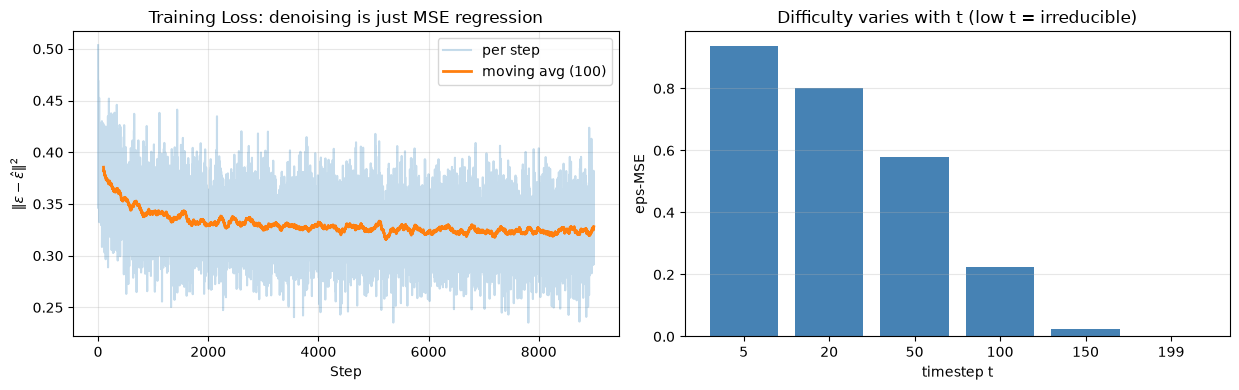

In [5]:
B = 128        # batch大小
P_DROP = 0.15  # CFG条件dropout概率:15%的样本把条件清零成"空条件"
STEPS = 9000
loss_hist = []

for step in range(1, STEPS + 1):
    # === DDPM Algorithm 1:抽图 -> 抽t -> 抽噪声 -> 闭式加噪 -> 回归eps ===
    idx = rng.integers(0, len(X_train), B)
    x0 = X_train[idx]
    cond = C_train[idx].copy()
    # 条件dropout:被抽中的样本条件清零,同一网络兼学"条件/无条件"两种去噪
    drop = rng.random(B) < P_DROP
    cond[drop] = 0.0
    t = rng.integers(0, T, B)  # 每个样本独立抽一个时间步:并行学习所有难度
    eps = rng.normal(0, 1, x0.shape)
    # 闭式跳步加噪:x_t = sqrt(abar_t)x_0 + sqrt(1-abar_t)eps,一步直达
    xt = sq_ab[t][:, None] * x0 + sq_1ab[t][:, None] * eps
    eps_hat, cache = forward(net, xt, t, cond)
    diff = eps_hat - eps
    # L_simple:纯MSE,不带ELBO里的加权项(DDPM发现simple版效果更好)
    loss = (diff ** 2).mean()
    deps = 2 * diff / diff.size  # MSE对eps_hat的梯度
    g = backward(net, cache, deps)
    # 学习率余弦退火:1.5e-3 -> 2e-4
    lr_t = 2e-4 + 0.5 * (1.5e-3 - 2e-4) * (1 + np.cos(np.pi * step / STEPS))
    adam_update(net, g, m, v, step, lr=lr_t)
    loss_hist.append(loss)
    if step % 1500 == 0:
        print(f'step {step}: loss={np.mean(loss_hist[-200:]):.4f}')

# 按t分段评估eps-MSE:看清"哪些时间步学得动、哪些本质不可学"
rng2 = np.random.default_rng(7)
t_buckets = [5, 20, 50, 100, 150, 199]
bucket_mse = []
for tval in t_buckets:
    idx = rng2.integers(0, len(X_train), 256)
    x0b, condb = X_train[idx], C_train[idx]
    tb = np.full(256, tval)
    epsb = rng2.normal(0, 1, x0b.shape)
    xtb = sq_ab[tb][:, None] * x0b + sq_1ab[tb][:, None] * epsb
    ehb, _ = forward(net, xtb, tb, condb)
    bucket_mse.append(((ehb - epsb) ** 2).mean())
    print(f't={tval}: eps-MSE={bucket_mse[-1]:.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4))
ax1.plot(loss_hist, alpha=0.25, label='per step')
# 滑动平均:np.convolve做100步窗口平滑,便于看趋势
smooth = np.convolve(loss_hist, np.ones(100) / 100, mode='valid')
ax1.plot(np.arange(len(smooth)) + 99, smooth, lw=2, label='moving avg (100)')
ax1.set_xlabel('Step'); ax1.set_ylabel(r'$\|\epsilon-\hat{\epsilon}\|^2$')
ax1.set_title('Training Loss: denoising is just MSE regression')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.bar([str(t) for t in t_buckets], bucket_mse, color='steelblue')
ax2.set_xlabel('timestep t'); ax2.set_ylabel('eps-MSE')
ax2.set_title('Difficulty varies with t (low t = irreducible)')
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## DDPM Ancestral Sampling with CFG(DDPM 祖先采样 + 无分类器引导)

#### 💻 代码解读

**做什么:** 实现完整的反向采样循环:从纯噪声 x_T 出发,一步步走回 x₀;每一步内置 classifier-free guidance。然后画出"图像从噪声中浮现"的中间状态序列。

**怎么做:**
- **CFG(采样侧)**:每一步做两次前向——一次带文本条件、一次空条件,然后外推 ε̂ = ε_uncond + w·(ε_cond − ε_uncond)。w=0 是纯无条件,w=1 是普通条件模型,**w>1 把"文本指向的方向"放大**,代价是两倍前向计算(Stable Diffusion 也一样)。注:原论文的参数化写作 (1+w)·ε_cond − w·ε_uncond,本文的 w 相当于论文的 w+1——这里沿用 Stable Diffusion guidance_scale 的通行惯例。
- **x̂₀ 裁剪技巧**:每步先由 ε̂ 反解出 x̂₀ = (x_t − √(1−ᾱ_t)·ε̂)/√ᾱ_t,把它裁剪到合法像素范围 [-1,1] 再计算后验均值(DDPM 官方实现的 clip-denoised 技巧)——对小模型 + 高引导强度尤其重要,防止外推把像素推爆。
- 后验均值用 DDPM 式(7):μ = c₁·x̂₀ + c₂·x_t,再加 √β̃_t 的噪声(最后一步 t=0 不加噪)。
- 序列图:三个 prompt 各一条去噪轨迹,形状约在 t≈90-60 之间从噪声中"显影"——正对应上一节 ε-MSE 弯折的中段时间步。

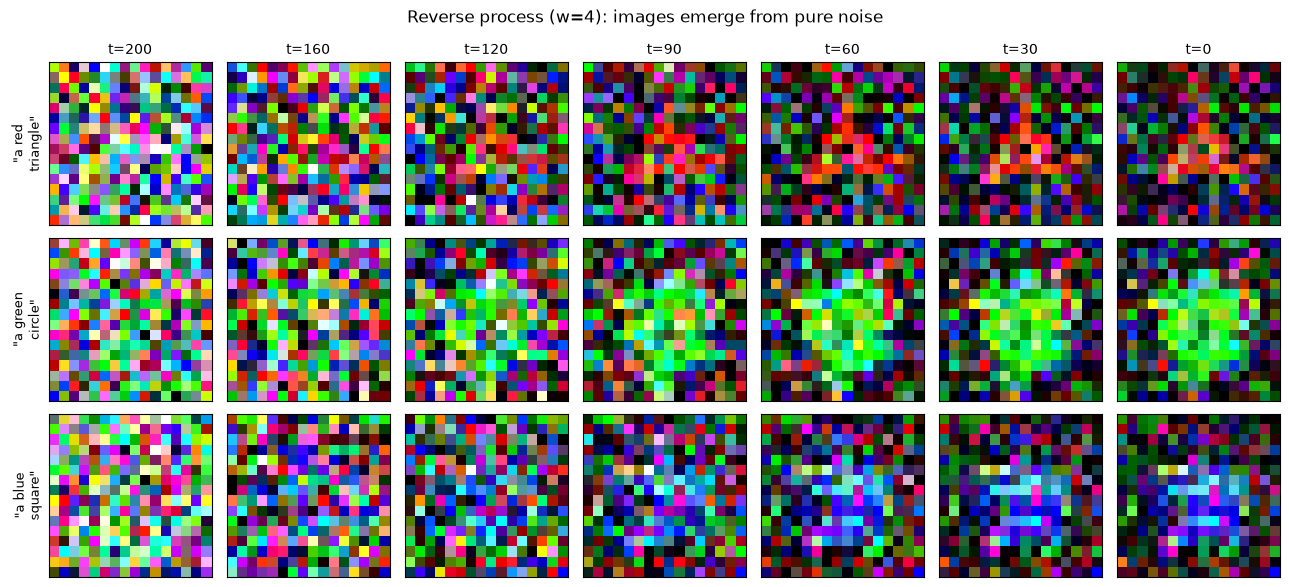

In [6]:
def sample(net, cond, w, rng, snap_ts=None):
    """DDPM ancestral sampling with classifier-free guidance.
    cond: (N, D_C) captions; w: guidance scale; returns final x (N, D_X)."""
    N = cond.shape[0]
    x = rng.normal(0, 1, (N, D_X))  # 从纯高斯噪声出发:x_T ~ N(0, I)
    null = np.zeros_like(cond)       # 空条件:全零词袋
    snaps = {T: x.copy()} if snap_ts is not None else None
    for ti in range(T - 1, -1, -1):
        t_arr = np.full(N, ti)
        # CFG核心:同一批x做两次前向(带条件/空条件),再外推组合
        e_c, _ = forward(net, x, t_arr, cond)
        e_u, _ = forward(net, x, t_arr, null)
        e = e_u + w * (e_c - e_u)  # w=0纯无条件, w=1纯条件, w>1放大文本方向
        # 由eps_hat反解x0_hat并裁剪到[-1,1](clip-denoised技巧,防外推爆掉)
        x0_hat = np.clip((x - sq_1ab[ti] * e) / sq_ab[ti], -1, 1)
        # DDPM式(7)后验均值:mu = c1*x0_hat + c2*x_t
        mean = (np.sqrt(abar_prev[ti]) * betas[ti] / (1 - abar[ti])) * x0_hat + \
               (np.sqrt(alphas[ti]) * (1 - abar_prev[ti]) / (1 - abar[ti])) * x
        # 祖先采样:除最后一步外,均值上再加posterior方差的噪声
        x = mean + (np.sqrt(post_var[ti]) * rng.normal(0, 1, x.shape) if ti > 0 else 0)
        if snap_ts is not None and ti in snap_ts:
            snaps[ti] = x.copy()
    return (x, snaps) if snap_ts is not None else x

# 三个prompt各采一条轨迹,记录中间状态:看图像如何从噪声中"显影"
snap_ts = [160, 120, 90, 60, 30, 0]
prompts3 = [('red', 'triangle'), ('green', 'circle'), ('blue', 'square')]
cond3 = np.array([caption_bow(c, s) for c, s in prompts3])
_, snaps = sample(net, cond3, 4.0, np.random.default_rng(21), snap_ts=set(snap_ts))

cols = [T] + snap_ts
fig, axes = plt.subplots(3, len(cols), figsize=(13, 6))
for i in range(3):
    for j, tv in enumerate(cols):
        ax = axes[i, j]
        ax.imshow(np.clip((snaps[tv][i].reshape(IMG, IMG, 3) + 1) / 2, 0, 1))
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title(f't={tv}', fontsize=10)
    axes[i, 0].set_ylabel(f'"a {prompts3[i][0]}\n{prompts3[i][1]}"', fontsize=9)
plt.suptitle('Reverse process (w=4): images emerge from pure noise', y=0.98)
plt.tight_layout(); plt.show()

## Guidance Scale Sweep(引导强度 w 扫描)

#### 💻 代码解读

**做什么:** 对同一个 prompt("a red triangle")扫描 w ∈ {0, 1, 2, 4, 8},每档生成 6 张样本——**每行使用完全相同的初始噪声**,唯一变量是 w。

**怎么做:**
- 每档 w 都用 `default_rng(33)` 新建生成器:随机流相同 → x_T 和每步注入的噪声都相同,不同行之间可以逐列对比,把 w 的效果与随机性隔离。
- 预期读图方式:w=0(无条件)行给出五颜六色的任意类别;w=1(普通条件)大致是红三角但常有杂色;w 越大样本越"标准",同时彼此越来越像——**贴合度换多样性**,与 Stable Diffusion 的 guidance scale 手感一致。

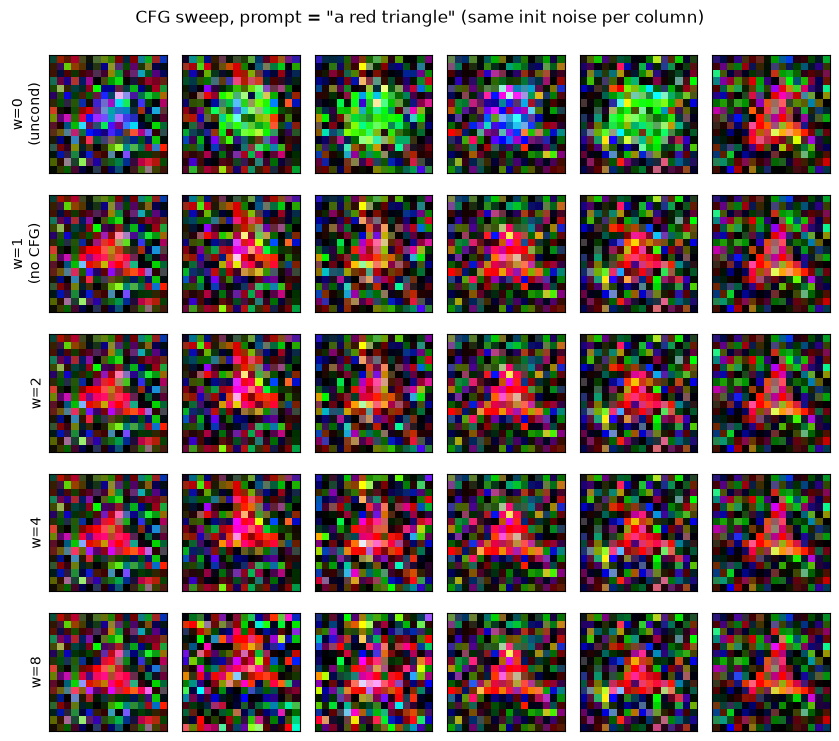

In [7]:
W_GRID = [0.0, 1.0, 2.0, 4.0, 8.0]
NSAMP = 6
cond_g = np.tile(caption_bow('red', 'triangle'), (NSAMP, 1))

fig, axes = plt.subplots(len(W_GRID), NSAMP, figsize=(8.5, 7.5))
for i, w in enumerate(W_GRID):
    # 每档w用相同种子33:同一批初始噪声,同一串采样噪声,唯一变量是w
    xs = sample(net, cond_g, w, np.random.default_rng(33))
    for j in range(NSAMP):
        ax = axes[i, j]
        ax.imshow(np.clip((xs[j].reshape(IMG, IMG, 3) + 1) / 2, 0, 1))
        ax.set_xticks([]); ax.set_yticks([])
    labels = {0: 'w=0\n(uncond)', 1: 'w=1\n(no CFG)'}
    axes[i, 0].set_ylabel(labels.get(w, f'w={w:g}'), fontsize=10)
plt.suptitle('CFG sweep, prompt = "a red triangle" (same init noise per column)', y=0.99)
plt.tight_layout(); plt.show()

## The Judge: A Classifier for Quantitative Evaluation(评委:用于量化评估的分类器)

#### 💻 代码解读

**做什么:** "看起来像"不算数——先在**真实数据**上训练一个 9 类小分类器当"评委",后面用它给生成图像的提示词依从率打分。

**怎么做:**
- 2 层 MLP(768→64→9)+ softmax 交叉熵,手写梯度(`P - onehot` 的经典形式),Adam 训 1200 步。
- **噪声增强**:训练时对每个 batch 的全部样本加噪,σ 逐样本从 [0,0.3] 均匀抽取——评委必须对扩散样本里的残余颗粒噪声鲁棒,否则它测的是"干净度"而不是"类别对不对"。
- 在 800 张全新真实图像上验证:准确率应 >95%,否则它没资格当评委。这个思路是 FID/CLIP-score 等生成评估指标的微缩版:**用一个独立训练的判别模型给生成模型打分**。

In [8]:
def init_clf(rng):
    """Tiny 2-layer classifier: 768 -> 64 -> 9"""
    return {
        'W1': rng.normal(0, np.sqrt(2 / D_X), (D_X, 64)), 'b1': np.zeros(64),
        'W2': rng.normal(0, np.sqrt(2 / 64), (64, 9)), 'b2': np.zeros(9),
    }

def clf_forward(p, x):
    h1p = x @ p['W1'] + p['b1']; h1 = np.maximum(h1p, 0)
    return h1 @ p['W2'] + p['b2'], (x, h1p, h1)

def softmax(L):
    # 数值稳定:每行减最大值再exp,防溢出
    L = L - L.max(1, keepdims=True)
    e = np.exp(L)
    return e / e.sum(1, keepdims=True)

clf = init_clf(rng)
mc = {k: np.zeros_like(v) for k, v in clf.items()}
vc = {k: np.zeros_like(vv) for k, vv in clf.items()}
# 独立测试集:评委必须在没见过的真实图像上>95%才有资格打分
X_test, C_test, y_test = make_dataset(800, rng)

for step in range(1, 1201):
    idx = rng.integers(0, len(X_train), 128)
    xb, yb = X_train[idx].copy(), y_train[idx]
    # 噪声增强:评委要对扩散样本的残余颗粒噪声鲁棒,不然测的是"干净度"
    sig = rng.uniform(0, 0.3, (len(xb), 1))
    xb = xb + sig * rng.normal(0, 1, xb.shape)
    logits, (xc, h1p, h1) = clf_forward(clf, xb)
    P = softmax(logits)
    # 交叉熵对logits的梯度=预测概率-onehot真值(与Paper 31同款推导)
    dlog = (P - np.eye(9)[yb]) / len(yb)
    g = {'W2': h1.T @ dlog, 'b2': dlog.sum(0)}
    dh1 = dlog @ clf['W2'].T * (h1p > 0)
    g['W1'] = xc.T @ dh1; g['b1'] = dh1.sum(0)
    adam_update(clf, g, mc, vc, step, lr=2e-3)

logits, _ = clf_forward(clf, X_test)
judge_acc = (logits.argmax(1) == y_test).mean()
print(f'Judge accuracy on held-out REAL images: {judge_acc:.1%} (must be >95% to qualify)')

Judge accuracy on held-out REAL images: 99.9% (must be >95% to qualify)


## Quantitative Evaluation: Prompt Adherence vs Guidance(量化评估:提示词依从率 vs 引导强度)

#### 💻 代码解读

**做什么:** 硬数字时间:对全部 9 个 prompt、每档 w 各生成 25 张图(每档共 225 张),让评委统计**依从率**——被判为目标类别的比例。

**怎么做:**
- 每档 w 一次性批量采样 225 张(`np.repeat` 把 9 个条件各复制 25 份),200 步循环内做 2×225 的批量前向——把采样也向量化,总耗时秒级。
- 同时从评委预测中拆出**颜色正确率**(pred//3)和**形状正确率**(pred%3),看模型先学会哪个属性。
- 关键对照:**w=0 应接近 1/9 随机线**(模型确实没用条件);**w=1(纯条件、无 CFG)是 baseline**;w≥2 的提升全部归功于 CFG 外推。柱状图同时画出随机线和 80% 目标线。

w=0: adherence=11.1%  (color 33.8%, shape 32.9%)


w=1: adherence=80.0%  (color 100.0%, shape 80.0%)


w=2: adherence=90.7%  (color 100.0%, shape 90.7%)


w=4: adherence=93.8%  (color 100.0%, shape 93.8%)


w=8: adherence=98.2%  (color 100.0%, shape 98.2%)

No guidance (w=1): 80.0%  ->  best CFG: 98.2%  (target: >=80%)


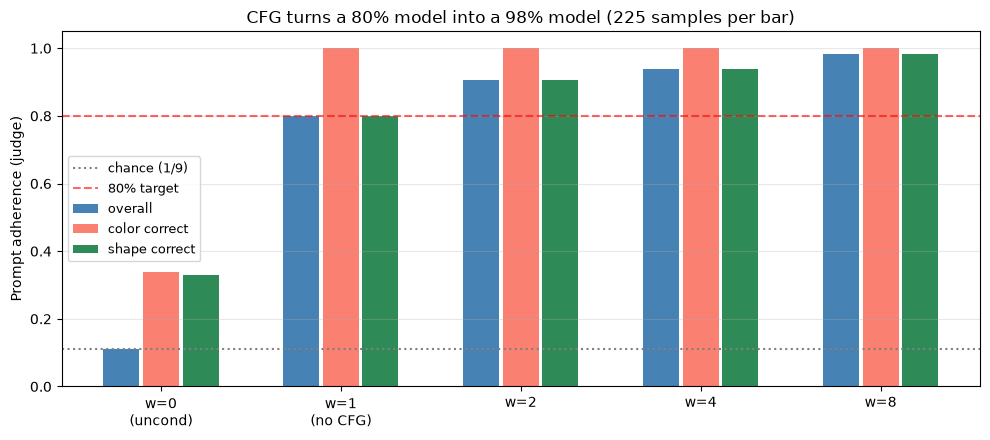

In [9]:
N_PER = 25  # 每个prompt每档w生成25张,9类共225张
W_LIST = [0.0, 1.0, 2.0, 4.0, 8.0]
prompt_conds = np.array([caption_bow(c, s) for c, s in ALL_PAIRS])
results = {}

for w in W_LIST:
    # np.repeat把9个条件各复制25份 -> (225, 7),一次批量采样全部生成
    cond = np.repeat(prompt_conds, N_PER, axis=0)
    y_target = np.repeat(np.arange(9), N_PER)
    xs = sample(net, cond, w, np.random.default_rng(int(10 + w * 10)))
    logits, _ = clf_forward(clf, xs)
    pred = logits.argmax(1)
    # 类别编号k=颜色*3+形状,整除/取余即可拆出两个属性的正确率
    results[w] = {
        'overall': (pred == y_target).mean(),
        'color': (pred // 3 == y_target // 3).mean(),
        'shape': (pred % 3 == y_target % 3).mean(),
    }
    r = results[w]
    print(f"w={w:g}: adherence={r['overall']:.1%}  (color {r['color']:.1%}, shape {r['shape']:.1%})")

base, cfg_best = results[1.0]['overall'], max(results[w]['overall'] for w in W_LIST if w > 1)
print(f'\nNo guidance (w=1): {base:.1%}  ->  best CFG: {cfg_best:.1%}  (target: >=80%)')

x_pos = np.arange(len(W_LIST))
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x_pos - 0.22, [results[w]['overall'] for w in W_LIST], 0.2, label='overall', color='steelblue')
ax.bar(x_pos, [results[w]['color'] for w in W_LIST], 0.2, label='color correct', color='salmon')
ax.bar(x_pos + 0.22, [results[w]['shape'] for w in W_LIST], 0.2, label='shape correct', color='seagreen')
ax.axhline(1 / 9, color='gray', ls=':', label='chance (1/9)')
ax.axhline(0.8, color='red', ls='--', alpha=0.6, label='80% target')
ax.set_xticks(x_pos)
ax.set_xticklabels(['w=0\n(uncond)', 'w=1\n(no CFG)', 'w=2', 'w=4', 'w=8'])
ax.set_ylabel('Prompt adherence (judge)')
ax.set_title(f'CFG turns a {results[1.0]["overall"]:.0%} model into a {results[8.0]["overall"]:.0%} model (225 samples per bar)')
ax.legend(loc='center left', fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 对照讨论:扩散 vs VAE(Paper 17)

同为"从高斯噪声造图像"的生成模型,17 号 VAE 和本篇扩散模型是两种世界观:

| | VAE (Paper 17) | 扩散 (本篇) |
|---|---|---|
| 生成方式 | **一步**:z → 解码器 → 图像 | **迭代精化**:200 步逐渐去噪 |
| 单步拟合的分布 | p(x\|z) 一步跨越"噪声→图像"的全部复杂度 | p(x_{t-1}\|x_t) 只是一个小方差高斯 |
| 后验/反向的假设 | 单峰对角高斯 q(z\|x)——表达力瓶颈,样本发糊 | 每步高斯假设**在小步长极限下渐近精确** |
| 训练目标 | ELBO = 重构 + KL,两项互相拉扯 | ELBO 化简后的纯 MSE(L_simple),训练极稳 |
| 采样成本 | 1 次前向 | 200×2 次前向(CFG 加倍)|

**为什么扩散画质上限更高:** VAE 的解码器必须用"单峰高斯 + 一次前向"覆盖从潜变量到图像的全部不确定性,多种可能的输出被平均成模糊;扩散把这段路切成 200 小步,每步的真实条件分布本来就接近高斯,假设与现实吻合,复合起来能表达任意复杂的分布——**用计算量换表达力**。有趣的闭环是:Latent Diffusion / Stable Diffusion 把两者合体——VAE 负责压缩(它擅长的重构),扩散负责在潜空间里生成(它擅长的分布拟合)。

另外两条与本仓库的暗线:重参数化技巧(VAE 用它让采样可导,扩散用它闭式跳步)与 ELBO(两者的训练目标都是它的变体)——同一套变分推断数学,长出了两代生成模型。

## Key Takeaways(要点总结)

**English:**
1. **Diffusion training is denoising regression**: sample an image, a timestep, a noise; regress the noise with plain MSE. No adversarial game, no KL balancing — loss fell smoothly to ~0.32
2. **The closed-form jump** q(x_t|x_0) = N(sqrt(abar_t) x_0, (1-abar_t) I) makes training O(1) per sample: Gaussians compose, so t steps of noising collapse into one
3. **Predicting eps (not x_0) keeps the regression target unit-variance at every t**; difficulty still varies (eps-MSE 0.000 at t=199 vs 0.937 at t=5, the irreducible end)
4. **Classifier-free guidance is extrapolation**: eps_u + w(eps_c - eps_u) with w>1 pushed prompt adherence from 80.0% (w=1) to 98.2% (w=8), judged by a 99.9%-accurate classifier — at the cost of diversity and 2x compute
5. **Fidelity-diversity tradeoff is visible**: same init noise, increasing w collapses colorful variety into on-prompt near-duplicates
6. **Scale this up and you get Stable Diffusion**: swap MLP for U-Net + cross-attention, bag-of-words for CLIP text embeddings, pixels for a VAE latent space (Rombach et al., 2022) — the mechanics in this notebook stay identical

**中文:**
1. **扩散训练=去噪回归**:抽图、抽 t、抽噪声,MSE 回归噪声。没有对抗、没有 KL 平衡,损失平滑降到 ~0.32
2. **闭式跳步公式**让训练每样本 O(1):高斯叠加仍是高斯,t 步加噪合并成一步
3. **预测 ε 而非 x₀**让回归目标在所有 t 上方差恒为 1;难度仍随 t 变化(t=199 时 MSE 0.000,t=5 时 0.937,后者不可约)
4. **CFG 是一种外推**:w>1 把依从率从 80.0% 推到 98.2%(99.9% 准确率的评委测定),代价是多样性下降和 2 倍计算
5. **贴合-多样性权衡肉眼可见**:同一批初始噪声,w 越大样本越贴题、也越雷同
6. **放大即 Stable Diffusion**:MLP 换 U-Net + 交叉注意力,词袋换 CLIP 文本嵌入,像素换 VAE 潜空间(Rombach et al., 2022)——本笔记本的机制原封不动

**与本仓库其他论文的联系:** 重参数化与 ELBO 承自 **17 号 VAE**(扩散是它的"多步版",Latent Diffusion 又把两者合体);解析跳连是 **10/15 号 ResNet** 残差思想在生成模型里的再现;正弦时间嵌入借自 **13 号 Transformer** 的位置编码;真实文生图的文本塔正是 **31 号 CLIP**;至此本仓库的多模态线(31-35)补齐了"理解"与"生成"两个半边——CLIP 把图文钉进同一空间,扩散再从那个空间里把图像"长"出来。